In [45]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [46]:
import os
os.listdir("data_madrid")


['dataset-copy.csv',
 'dataset.csv',
 'dataset_clean.csv',
 'datClean.csv',
 'Datos.csv']

In [47]:
df.to_csv("data_madrid/dataset_clean.csv", index=False)


In [48]:
df = pd.read_csv("data_madrid/datClean.csv")


#  Modelado de Regresión - Random Forest

En este notebook vamos a entrenar un modelo de regresión para predecir el precio actual de las viviendas utilizando el algoritmo Random Forest.


## Definición de variables

- X → Variables predictoras
- y → Variable objetivo (PrecioActual)

Separamos el dataset en características y variable objetivo.


In [49]:
X = df.drop("PrecioActual", axis=1)
y = df["PrecioActual"]

X.shape, y.shape


((11822, 7), (11822,))

## División Train/Test

Dividimos los datos en:

- 80% entrenamiento
- 20% prueba

Esto nos permite evaluar el modelo en datos no vistos.


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


##  Entrenamiento del modelo

Utilizamos Random Forest Regressor, un modelo basado en múltiples árboles de decisión.

Este modelo:
- Reduce el overfitting
- Maneja bien relaciones no lineales
- Es robusto ante ruido


In [51]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Predicciones

Realizamos predicciones sobre el conjunto de test.


In [52]:
y_pred = rf.predict(X_test)


## Evaluación del modelo

Evaluamos el rendimiento utilizando:

- MAE → Error absoluto medio
- RMSE → Penaliza más los errores grandes
- R² → Proporción de varianza explicada


In [53]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 194271.91009634192
RMSE: 464970.47590088256
R2  : 0.8499948320911838


##  Importancia de variables

Analizamos qué variables influyen más en la predicción del precio.


In [54]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

importances.head(10)


metros              0.737495
zona_id             0.155149
plantaN             0.057567
habitaciones        0.029220
tipo_inmueble_id    0.012536
ascensor            0.006288
localizacion        0.001745
dtype: float64

# Optimización del modelo



Ajustamos algunos hiperparámetros del Random Forest para mejorar el rendimiento.

Los principales parámetros ajustados son:
- n_estimators → número de árboles
- max_depth → profundidad máxima de los árboles
- min_samples_split → mínimo de muestras para dividir un nodo


In [55]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Mejores parámetros:", grid.best_params_)


Mejores parámetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 500}


Evaluación del modelo optimizado 

In [56]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 211288.61901016076
RMSE: 463644.7842113584
R2  : 0.8508489814446064


# Gráfico Real vs Predicción

## Comparación: valores reales vs predichos

Visualizamos la relación entre el precio real y el precio predicho.
Si el modelo es bueno, los puntos deberían alinearse cerca de la línea diagonal.


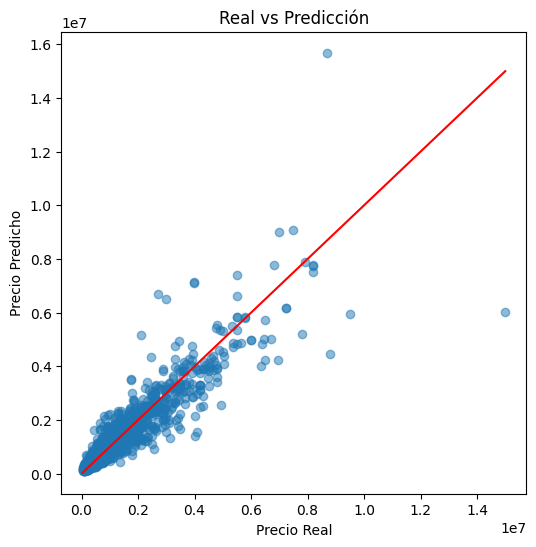

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Real vs Predicción")
plt.show()


In [60]:
df["PrecioActual"].mean()


np.float64(1029798.1109795297)

## Análisis de viviendas con más de 800 m²

Evaluamos cuántas viviendas superan los 800 m² para determinar si pueden considerarse outliers.


## Eliminación de outliers en metros

Para mejorar la estabilidad del modelo, eliminamos viviendas con más de 800 m²,
ya que representan valores extremos poco frecuentes.


In [62]:
print("Tamaño original:", df.shape)

df_model = df[df["metros"] <= 800]

print("Tamaño tras eliminar >800 m²:", df_model.shape)


Tamaño original: (11822, 8)
Tamaño tras eliminar >800 m²: (11735, 8)


In [63]:
X = df_model.drop("PrecioActual", axis=1)
y = df_model["PrecioActual"]


## Análisis de viviendas con precio superior a 700.000 €

Evaluamos cuántas viviendas superan los 700.000 € para determinar si pueden considerarse valores extremos dentro del mercado.


In [64]:
mayores_700k = df[df["PrecioActual"] > 700000].shape[0]
total = df.shape[0]

print("Viviendas > 700.000 €:", mayores_700k)
print("Porcentaje:", round((mayores_700k / total) * 100, 2), "%")


Viviendas > 700.000 €: 5416
Porcentaje: 45.81 %


## Distribución del precio de las viviendas

Visualizamos la distribución del precio para detectar asimetrías y posibles valores extremos.


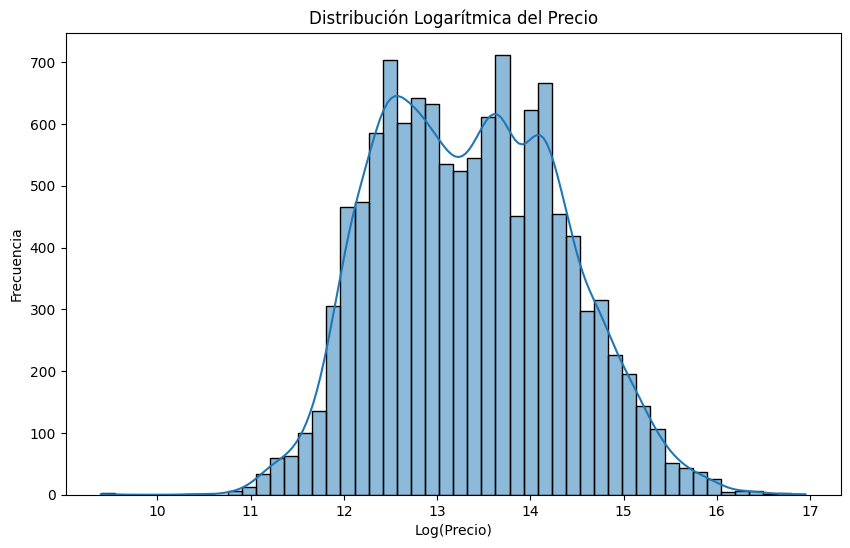

In [66]:
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df["PrecioActual"]), bins=50, kde=True)
plt.title("Distribución Logarítmica del Precio")
plt.xlabel("Log(Precio)")
plt.ylabel("Frecuencia")
plt.show()


In [68]:
y = np.log1p(df["PrecioActual"])


In [70]:
%who


GridSearchCV	 RandomForestRegressor	 X	 X_test	 X_train	 best_model	 df	 df_model	 grid	 
importances	 mae	 mayores_700k	 mean_absolute_error	 mean_squared_error	 np	 os	 param_grid	 pd	 
plt	 r2	 r2_score	 rf	 rmse	 sns	 total	 train_test_split	 y	 
y_pred	 y_test	 y_train	 


In [ ]:
#  Transformamos el target
y = np.log1p(df_model["PrecioActual"])
X = df_model.drop("PrecioActual", axis=1)

# Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Entrenamos modelo optimizado (si usaste GridSearch antes, vuelve a entrenar)
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predicción en log
y_pred_log = rf.predict(X_test)

# Volvemos a escala real
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

# Métricas reales
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 188587.41422293943
RMSE: 393996.8404983486
R2: 0.8862403975619484


## Evaluación del overfitting

Comparamos el rendimiento del modelo en el conjunto de entrenamiento y en el conjunto de prueba.
Si la diferencia es grande, el modelo está sobreajustando.


In [ ]:
# Predicciones en TRAIN
y_train_pred_log = rf.predict(X_train)
y_train_pred = np.expm1(y_train_pred_log)
y_train_real = np.expm1(y_train)


# R2
r2_train = r2_score(y_train_real, y_train_pred)
r2_test = r2_score(y_test_real, y_pred)

print("R2 Train:", round(r2_train,4))
print("R2 Test:", round(r2_test,4))

print("Diferencia:", round(r2_train - r2_test,4))


R2 Train: 0.9347
R2 Test: 0.8866
Diferencia: 0.048


In [77]:
overfit_pct = ((r2_train - r2_test) / r2_train) * 100
print("Overfitting %:", round(overfit_pct,2), "%")


Overfitting %: 5.14 %
